# TransferJudge EDA: Amazon Reviews 2023

**목적**: 실험 설계의 핵심 가정을 데이터로 검증
- Overlapping User 1,000명 추출 가능성
- 리뷰 토큰 예산 검증 (Source 30개 + Target 10개)
- Cold-Start 기준(5~10개), GT 확보율, 메타데이터 품질

## 0. 환경 설정

In [6]:
# !pip install datasets pandas tiktoken matplotlib seaborn pyarrow

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from datasets import load_dataset
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

# tiktoken 인코더 (GPT-4o-mini / Qwen3 토큰 수 근사치로 사용)
enc = tiktoken.get_encoding('cl100k_base')

def count_tokens(text):
    """텍스트의 토큰 수 반환. None/빈 문자열은 0."""
    if not text or not isinstance(text, str):
        return 0
    return len(enc.encode(text))

print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 다운로드 및 로딩

Amazon Reviews 2023 (McAuley Lab) — HuggingFace datasets

In [8]:
# ============================================================
# 1-1. 리뷰 데이터 로딩
# ============================================================
# Movies & TV: ~8.8M건, Books: ~28.6M건
# Books가 매우 크므로 메모리 부족 시 streaming=True로 전환

print('Movies & TV 리뷰 로딩...')
movies_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_review_Movies_and_TV',
    split='full',
    trust_remote_code=True
)
print(f'  Movies & TV: {len(movies_ds):,}건')

print('Books 리뷰 로딩...')
books_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_review_Books',
    split='full',
    trust_remote_code=True
)
print(f'  Books: {len(books_ds):,}건')

Movies & TV 리뷰 로딩...
  Movies & TV: 17,328,314건
Books 리뷰 로딩...


Loading dataset shards:   0%|          | 0/33 [00:00<?, ?it/s]

  Books: 29,475,453건


In [9]:
# ============================================================
# 1-2. DataFrame 변환 (필요 컬럼만)
# ============================================================
REVIEW_COLS = ['user_id', 'parent_asin', 'rating', 'text', 'title', 'timestamp']

print('DataFrame 변환 중...')
movies_df = movies_ds.to_pandas()[REVIEW_COLS].copy()
books_df = books_ds.to_pandas()[REVIEW_COLS].copy()

# 메모리 절약: 원본 dataset 해제
del movies_ds, books_ds

# timestamp 변환 (ms → datetime)
movies_df['datetime'] = pd.to_datetime(movies_df['timestamp'], unit='ms')
books_df['datetime'] = pd.to_datetime(books_df['timestamp'], unit='ms')

print(f'Movies & TV: {len(movies_df):,}건, Books: {len(books_df):,}건')
print(f'\nMovies 샘플:')
movies_df.head(2)

DataFrame 변환 중...
Movies & TV: 17,328,314건, Books: 29,475,453건

Movies 샘플:


,user_id,parent_asin,rating,text,title,timestamp,datetime
0,AGGZ357AO26RQZVRLGU4D4N52DZQ,B013488XFS,5.0,"Amazon, please buy the show! I'm hooked!",Five Stars,1440385637000,2015-08-24 03:07:17
1,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B00CB6VTDS,5.0,My Kiddos LOVE this show!!,Five Stars,1461100610000,2016-04-19 21:16:50


In [10]:
# ============================================================
# 1-2.5 로우데이터 구조 탐색
# ============================================================
# 원본 데이터 스키마 및 샘플 확인

print('=== Movies & TV 리뷰 원본 구조 ===')
print(f'컬럼: {list(movies_df.columns)}')
print(f'shape: {movies_df.shape}')
print(f'dtypes:\n{movies_df.dtypes}\n')
print('--- 샘플 2건 ---')
display(movies_df.head(2))

print('\n=== Books 리뷰 원본 구조 ===')
print(f'컬럼: {list(books_df.columns)}')
print(f'shape: {books_df.shape}')
print(f'dtypes:\n{books_df.dtypes}\n')
print('--- 샘플 2건 ---')
display(books_df.head(2))

# 기본 통계
print('\n=== 기본 통계 ===')
for df, label in [(movies_df, 'Movies & TV'), (books_df, 'Books')]:
    print(f'\n{label}:')
    print(f'  전체 리뷰 수:    {len(df):,}')
    print(f'  고유 사용자 수:  {df["user_id"].nunique():,}')
    print(f'  고유 아이템 수:  {df["parent_asin"].nunique():,}')
    print(f'  평점 범위:       {df["rating"].min():.1f} ~ {df["rating"].max():.1f}')
    print(f'  기간:            {df["datetime"].min().strftime("%Y-%m")} ~ {df["datetime"].max().strftime("%Y-%m")}')
    print(f'  text 결측:       {df["text"].isna().sum():,} ({df["text"].isna().mean()*100:.2f}%)')


=== Movies & TV 리뷰 원본 구조 ===
컬럼: ['user_id', 'parent_asin', 'rating', 'text', 'title', 'timestamp', 'datetime']
shape: (17328314, 7)
dtypes:
user_id                object
parent_asin            object
rating                float64
text                   object
title                  object
timestamp               int64
datetime       datetime64[ns]
dtype: object

--- 샘플 2건 ---


,user_id,parent_asin,rating,text,title,timestamp,datetime
0,AGGZ357AO26RQZVRLGU4D4N52DZQ,B013488XFS,5.0,"Amazon, please buy the show! I'm hooked!",Five Stars,1440385637000,2015-08-24 03:07:17
1,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B00CB6VTDS,5.0,My Kiddos LOVE this show!!,Five Stars,1461100610000,2016-04-19 21:16:50



=== Books 리뷰 원본 구조 ===
컬럼: ['user_id', 'parent_asin', 'rating', 'text', 'title', 'timestamp', 'datetime']
shape: (29475453, 7)
dtypes:
user_id                object
parent_asin            object
rating                float64
text                   object
title                  object
timestamp               int64
datetime       datetime64[ns]
dtype: object

--- 샘플 2건 ---


,user_id,parent_asin,rating,text,title,timestamp,datetime
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B09BGPFTDB,1.0,It is definitely not a watercolor book. The p...,Not a watercolor book! Seems like copies imo.,1642399598485,2022-01-17 06:06:38.485
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0593235657,5.0,Updated: after first book arrived very damaged...,Updated: after 1st arrived damaged this one is...,1640629604904,2021-12-27 18:26:44.904



=== 기본 통계 ===

Movies & TV:
  전체 리뷰 수:    17,328,314
  고유 사용자 수:  6,503,429
  고유 아이템 수:  747,764
  평점 범위:       1.0 ~ 5.0
  기간:            1997-08 ~ 2023-09
  text 결측:       0 (0.00%)

Books:
  전체 리뷰 수:    29,475,453
  고유 사용자 수:  10,297,355
  고유 아이템 수:  4,446,065
  평점 범위:       0.0 ~ 5.0
  기간:            1996-06 ~ 2023-09
  text 결측:       0 (0.00%)


In [11]:
# ============================================================
# 1-3. 기본 전처리: 빈 리뷰 제거
# ============================================================
print('전처리 전:')
print(f'  Movies: {len(movies_df):,}, Books: {len(books_df):,}')

# text가 null이거나 빈 문자열인 행 제거
movies_df = movies_df[movies_df['text'].notna() & (movies_df['text'].str.strip() != '')].copy()
books_df = books_df[books_df['text'].notna() & (books_df['text'].str.strip() != '')].copy()

print('전처리 후:')
print(f'  Movies: {len(movies_df):,}, Books: {len(books_df):,}')
print(f'  제거율 — Movies: {100-len(movies_df)/len(movies_df)*100:.1f}%, Books: {100-len(books_df)/len(books_df)*100:.1f}%')

전처리 전:
  Movies: 17,328,314, Books: 29,475,453
전처리 후:
  Movies: 17,327,095, Books: 29,467,817
  제거율 — Movies: 0.0%, Books: 0.0%


## 2. Overlapping User 추출 및 분포 분석

In [12]:
# ============================================================
# 2-1. 사용자별 리뷰 수 집계
# ============================================================
movies_user_counts = movies_df.groupby('user_id').size().reset_index(name='movie_count')
books_user_counts = books_df.groupby('user_id').size().reset_index(name='book_count')

# Overlapping user 찾기
overlap_df = movies_user_counts.merge(books_user_counts, on='user_id', how='inner')

print(f'전체 Movies 사용자: {len(movies_user_counts):,}')
print(f'전체 Books 사용자:  {len(books_user_counts):,}')
print(f'Overlapping 사용자: {len(overlap_df):,}')
print(f'\nOverlapping 사용자 리뷰 수 통계:')
overlap_df[['movie_count', 'book_count']].describe().round(1)

전체 Movies 사용자: 6,502,818
전체 Books 사용자:  10,292,988
Overlapping 사용자: 2,530,704

Overlapping 사용자 리뷰 수 통계:


,movie_count,book_count
count,2530704.0,2530704.0
mean,3.8,4.6
std,11.9,16.6
min,1.0,1.0
25%,1.0,1.0
50%,2.0,2.0
75%,3.0,4.0
max,4369.0,3888.0


In [13]:
# ============================================================
# 2-2. 조건별 사용자 수 탐색 (EDA-1)
# ============================================================
# Source 기준을 1부터 넓게 탐색하여 5개 이하 분포도 파악

source_thresholds = [1, 3, 5, 10, 15, 20, 30]
target_ranges = [(1, 5), (3, 10), (5, 10), (5, 15), (5, 20)]

print('=== 조건별 Overlapping User 수 ===')
print(f'{"":>20}', end='')
for t_lo, t_hi in target_ranges:
    print(f'  Target {t_lo}~{t_hi:>2}', end='')
print()

results = {}
for s_min in source_thresholds:
    print(f'Source >= {s_min:>2}개:     ', end='')
    for t_lo, t_hi in target_ranges:
        count = len(overlap_df[
            (overlap_df['movie_count'] >= s_min) &
            (overlap_df['book_count'] >= t_lo) &
            (overlap_df['book_count'] <= t_hi)
        ])
        results[(s_min, t_lo, t_hi)] = count
        print(f'  {count:>10,}', end='')
    print()

# 본 연구 조건 강조
our_count = results.get((15, 5, 10), 0)
print(f'\n★ 본 연구 조건 (Source>=15, Target 5~10): {our_count:,}명')
print(f'  목표 1,000명 대비: {"✅ 충분" if our_count >= 1000 else "⚠️ 부족 — 기준 완화 필요"}')


=== 조건별 Overlapping User 수 ===
                      Target 1~ 5  Target 3~10  Target 5~10  Target 5~15  Target 5~20
Source >=  1개:        2,073,112     800,355     367,180     453,055     493,075
Source >=  3개:          616,104     327,426     167,751     214,686     238,503
Source >=  5개:          302,312     184,739     100,034     131,088     147,749
Source >= 10개:           98,084      71,670      41,591      56,885      65,605
Source >= 15개:           47,058      37,447      22,465      31,450      36,891
Source >= 20개:           27,278      22,835      13,984      19,879      23,621
Source >= 30개:           12,273      10,665       6,629       9,632      11,673

★ 본 연구 조건 (Source>=15, Target 5~10): 22,465명
  목표 1,000명 대비: ✅ 충분


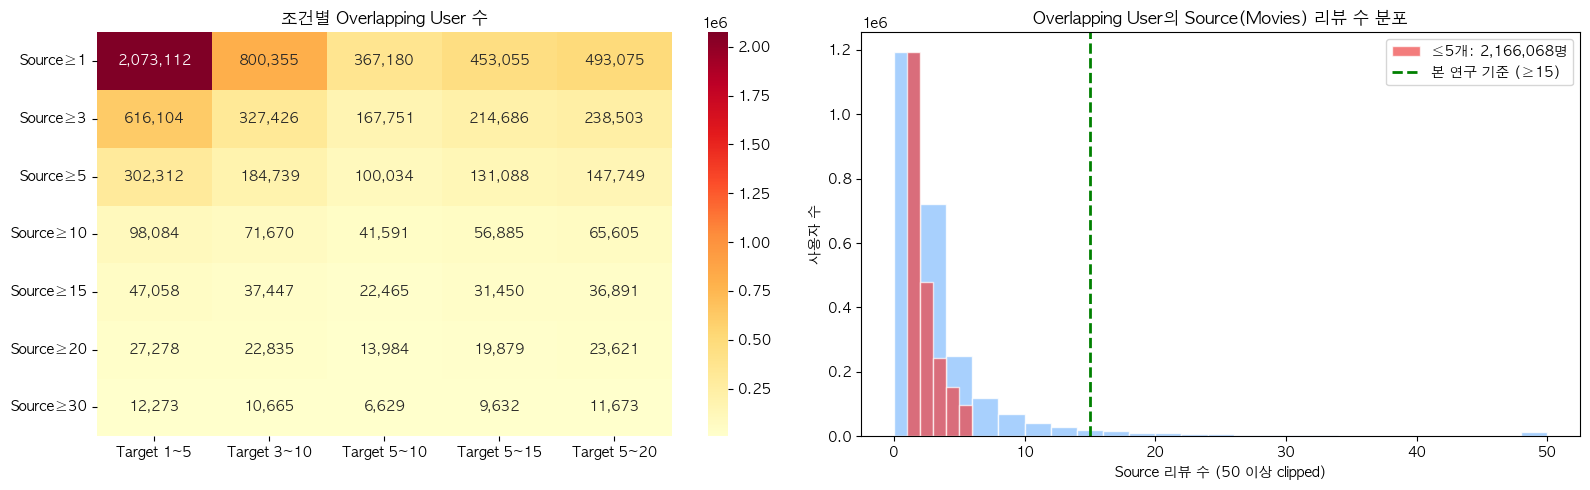


=== Overlapping User의 Source 리뷰 수 구간별 분포 ===
     1~2개: 1,672,422명 ( 66.1%)
     3~5개:  493,646명 ( 19.5%)
    6~10개:  211,124명 (  8.3%)
   11~15개:   67,346명 (  2.7%)
   16~20개:   30,678명 (  1.2%)
   21~30개:   26,848명 (  1.1%)
   31~50개:   16,597명 (  0.7%)
     51+개:   12,043명 (  0.5%)


In [14]:
# ============================================================
# 2-3. 시각화: 조건별 히트맵 + Source 전체 분포 (5개 이하 포함)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (좌) 히트맵
heatmap_data = pd.DataFrame(
    [[results.get((s, t_lo, t_hi), 0) for t_lo, t_hi in target_ranges] for s in source_thresholds],
    index=[f'Source≥{s}' for s in source_thresholds],
    columns=[f'Target {t_lo}~{t_hi}' for t_lo, t_hi in target_ranges]
)
sns.heatmap(heatmap_data, annot=True, fmt=',', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('조건별 Overlapping User 수')

# (우) Source 리뷰 수 전체 분포 (1개부터, 5개 이하 구간 강조)
src_counts = overlap_df['movie_count']
bins = list(range(0, 52, 2)) + [src_counts.max() + 1]
axes[1].hist(src_counts.clip(upper=50), bins=range(0, 52, 2), color='#93C5FD', edgecolor='white', alpha=0.8)
# 5개 이하 구간 강조
under5 = src_counts[src_counts <= 5]
axes[1].hist(under5, bins=range(0, 7), color='#EF4444', edgecolor='white', alpha=0.7, label=f'≤5개: {len(under5):,}명')
# 15개 기준선
axes[1].axvline(x=15, color='green', linestyle='--', linewidth=2, label='본 연구 기준 (≥15)')
axes[1].set_title('Overlapping User의 Source(Movies) 리뷰 수 분포')
axes[1].set_xlabel('Source 리뷰 수 (50 이상 clipped)')
axes[1].set_ylabel('사용자 수')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_overlap_heatmap.png', dpi=150)
plt.show()

# Source 리뷰 수 구간별 사용자 수
print('\n=== Overlapping User의 Source 리뷰 수 구간별 분포 ===')
intervals = [(1, 2), (3, 5), (6, 10), (11, 15), (16, 20), (21, 30), (31, 50), (51, None)]
for lo, hi in intervals:
    if hi is None:
        mask = src_counts >= lo
        label = f'{lo}+'
    else:
        mask = (src_counts >= lo) & (src_counts <= hi)
        label = f'{lo}~{hi}'
    cnt = mask.sum()
    print(f'  {label:>6}개: {cnt:>8,}명 ({cnt/len(overlap_df)*100:5.1f}%)')


In [15]:
# ============================================================
# 2-4. 본 연구 조건 적용 → 대상 사용자 확정
# ============================================================
TARGET_SOURCE_MIN = 15
TARGET_BOOK_MIN = 5
TARGET_BOOK_MAX = 10
TARGET_USER_COUNT = 1000

qualified = overlap_df[
    (overlap_df['movie_count'] >= TARGET_SOURCE_MIN) &
    (overlap_df['book_count'] >= TARGET_BOOK_MIN) &
    (overlap_df['book_count'] <= TARGET_BOOK_MAX)
].copy()

print(f'조건 충족 사용자: {len(qualified):,}명')

# GT 확보: rating >= 4인 구매가 1개 이상 있는 사용자
qualified_users = set(qualified['user_id'])
books_qualified = books_df[books_df['user_id'].isin(qualified_users)].copy()
books_qualified = books_qualified.sort_values(['user_id', 'timestamp'])

# 각 사용자별 rating >= 4인 리뷰 중 가장 최근 것을 GT로 사용
books_positive = books_qualified[books_qualified['rating'] >= 4.0]
gt_candidates = books_positive.groupby('user_id').last()  # 시간순 정렬 후 마지막 = 가장 최근

print(f'GT(rating≥4 중 가장 최근) 확보 가능: {len(gt_candidates):,}명 ({len(gt_candidates)/len(qualified)*100:.1f}%)')

# 참고: 기존 방식(마지막 구매가 반드시 4점 이상)과 비교
last_reviews = books_qualified.groupby('user_id').last()
old_gt = last_reviews[last_reviews['rating'] >= 4.0]
print(f'  (참고) 마지막 구매가 4점 이상인 사용자: {len(old_gt):,}명 ({len(old_gt)/len(qualified)*100:.1f}%)')
print(f'  → 새 방식으로 {len(gt_candidates) - len(old_gt):,}명 추가 확보')

# 최종 대상 사용자 샘플링
# 하위 호환: gt_available 변수도 유지
gt_available = gt_candidates
final_user_pool = set(gt_candidates.index)
if len(final_user_pool) >= TARGET_USER_COUNT:
    np.random.seed(42)
    final_users = set(np.random.choice(list(final_user_pool), TARGET_USER_COUNT, replace=False))
    print(f'\n✅ {TARGET_USER_COUNT}명 랜덤 샘플링 완료 (seed=42)')
else:
    final_users = final_user_pool
    print(f'\n⚠️ {len(final_user_pool)}명만 확보 — 기준 완화 검토 필요')


조건 충족 사용자: 22,465명
GT(rating≥4 중 가장 최근) 확보 가능: 22,364명 (99.6%)
  (참고) 마지막 구매가 4점 이상인 사용자: 18,898명 (84.1%)
  → 새 방식으로 3,466명 추가 확보

✅ 1000명 랜덤 샘플링 완료 (seed=42)


## 3. 리뷰 수 분포 (EDA-2)

In [16]:
# ============================================================
# 3-1. 최종 대상 사용자의 도메인별 리뷰 수 분포
# ============================================================
final_overlap = overlap_df[overlap_df['user_id'].isin(final_users)].copy()

print('=== 최종 대상 사용자 리뷰 수 통계 ===')
for col, label in [('movie_count', 'Source (Movies & TV)'), ('book_count', 'Target (Books)')]:
    s = final_overlap[col]
    print(f'\n{label}:')
    print(f'  Mean: {s.mean():.1f}, Median: {s.median():.0f}')
    print(f'  P25: {s.quantile(0.25):.0f}, P75: {s.quantile(0.75):.0f}, P95: {s.quantile(0.95):.0f}')
    print(f'  Min: {s.min()}, Max: {s.max()}')

=== 최종 대상 사용자 리뷰 수 통계 ===

Source (Movies & TV):
  Mean: 31.7, Median: 22
  P25: 17, P75: 33, P95: 71
  Min: 15, Max: 629

Target (Books):
  Mean: 7.0, Median: 7
  P25: 6, P75: 8, P95: 10
  Min: 5, Max: 10


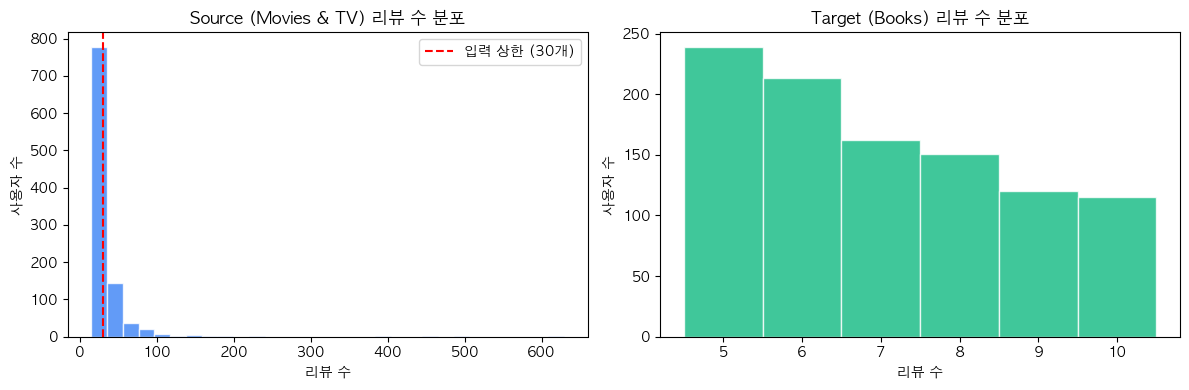

In [17]:
# ============================================================
# 3-2. 시각화: 리뷰 수 히스토그램
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Source
axes[0].hist(final_overlap['movie_count'], bins=30, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[0].axvline(x=30, color='red', linestyle='--', label='입력 상한 (30개)')
axes[0].set_title('Source (Movies & TV) 리뷰 수 분포')
axes[0].set_xlabel('리뷰 수')
axes[0].set_ylabel('사용자 수')
axes[0].legend()

# Target
axes[1].hist(final_overlap['book_count'], bins=range(5, 12), color='#10B981', edgecolor='white', alpha=0.8, align='left')
axes[1].set_title('Target (Books) 리뷰 수 분포')
axes[1].set_xlabel('리뷰 수')
axes[1].set_ylabel('사용자 수')
axes[1].set_xticks(range(5, 11))

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_review_count_dist.png', dpi=150)
plt.show()

## 4. 리뷰 토큰 수 분포 (EDA-3) ⭐ 핵심

In [18]:
# ============================================================
# 4-1. 대상 사용자 리뷰만 추출
# ============================================================
movies_final = movies_df[movies_df['user_id'].isin(final_users)].copy()
books_final = books_df[books_df['user_id'].isin(final_users)].copy()

print(f'대상 사용자 리뷰 — Movies: {len(movies_final):,}건, Books: {len(books_final):,}건')

대상 사용자 리뷰 — Movies: 31,655건, Books: 7,045건


In [19]:
# ============================================================
# 4-2. 토큰 수 측정
# ============================================================
# 대상 사용자 리뷰에 대해서만 측정 (전체 데이터는 너무 오래 걸림)
print('토큰 수 측정 중 (수 분 소요)...')

movies_final['token_count'] = movies_final['text'].apply(count_tokens)
books_final['token_count'] = books_final['text'].apply(count_tokens)

print('완료!')

토큰 수 측정 중 (수 분 소요)...
완료!


In [20]:
# ============================================================
# 4-3. 토큰 통계 출력
# ============================================================
print('=== 리뷰 토큰 수 통계 ===')
print(f'선행연구 참조값: Movies ~58 tokens, Books ~98 tokens\n')

for df, label in [(movies_final, 'Source (Movies & TV)'), (books_final, 'Target (Books)')]:
    s = df['token_count']
    print(f'{label}:')
    print(f'  Mean:   {s.mean():.1f} tokens')
    print(f'  Median: {s.median():.0f} tokens')
    print(f'  P75:    {s.quantile(0.75):.0f} tokens')
    print(f'  P95:    {s.quantile(0.95):.0f} tokens')
    print(f'  Max:    {s.max():,} tokens')
    print()

=== 리뷰 토큰 수 통계 ===
선행연구 참조값: Movies ~58 tokens, Books ~98 tokens

Source (Movies & TV):
  Mean:   80.4 tokens
  Median: 28 tokens
  P75:    73 tokens
  P95:    343 tokens
  Max:    4,749 tokens

Target (Books):
  Mean:   67.3 tokens
  Median: 30 tokens
  P75:    69 tokens
  P95:    266 tokens
  Max:    1,872 tokens



In [21]:
# ============================================================
# 4-4. 토큰 예산 검증 ⭐
# ============================================================
m_mean = movies_final['token_count'].mean()
m_p95 = movies_final['token_count'].quantile(0.95)
b_mean = books_final['token_count'].mean()
b_p95 = books_final['token_count'].quantile(0.95)

PROMPT_TOKENS = 500  # 시스템 프롬프트

print('=== Profiler 입력 토큰 예산 검증 ===')
print(f'\n[평균 기준]')
avg_total = m_mean * 30 + b_mean * 10 + PROMPT_TOKENS
print(f'  Source 30개: {m_mean:.0f} × 30 = {m_mean*30:,.0f}')
print(f'  Target 10개: {b_mean:.0f} × 10 = {b_mean*10:,.0f}')
print(f'  프롬프트:    {PROMPT_TOKENS}')
print(f'  합계:        {avg_total:,.0f} tokens')

print(f'\n[P95 Worst-case]')
p95_total = m_p95 * 30 + b_p95 * 10 + PROMPT_TOKENS
print(f'  Source 30개: {m_p95:.0f} × 30 = {m_p95*30:,.0f}')
print(f'  Target 10개: {b_p95:.0f} × 10 = {b_p95*10:,.0f}')
print(f'  프롬프트:    {PROMPT_TOKENS}')
print(f'  합계:        {p95_total:,.0f} tokens')

print(f'\n[판정]')
print(f'  GPT-4o-mini (128K context): {"✅ 여유" if p95_total < 128000 else "⚠️ 초과"}')
print(f'  Qwen3-14B (4,096 생성):     {"✅ 가능" if p95_total < 32000 else "⚠️ context 확인 필요"}')

if m_p95 > 58 * 2:
    print(f'\n⚠️ Movies P95({m_p95:.0f})이 참조값(58)의 2배 초과 — Source 입력 수 축소 검토')
    safe_count = int(3000 / m_p95)
    print(f'   → P95 기준 안전 입력 수: {safe_count}개')
if b_p95 > 98 * 2:
    print(f'\n⚠️ Books P95({b_p95:.0f})이 참조값(98)의 2배 초과 — Target 입력 수 축소 검토')
    safe_count = int(2000 / b_p95)
    print(f'   → P95 기준 안전 입력 수: {safe_count}개')

=== Profiler 입력 토큰 예산 검증 ===

[평균 기준]
  Source 30개: 80 × 30 = 2,412
  Target 10개: 67 × 10 = 673
  프롬프트:    500
  합계:        3,585 tokens

[P95 Worst-case]
  Source 30개: 343 × 30 = 10,290
  Target 10개: 266 × 10 = 2,658
  프롬프트:    500
  합계:        13,448 tokens

[판정]
  GPT-4o-mini (128K context): ✅ 여유
  Qwen3-14B (4,096 생성):     ✅ 가능

⚠️ Movies P95(343)이 참조값(58)의 2배 초과 — Source 입력 수 축소 검토
   → P95 기준 안전 입력 수: 8개

⚠️ Books P95(266)이 참조값(98)의 2배 초과 — Target 입력 수 축소 검토
   → P95 기준 안전 입력 수: 7개


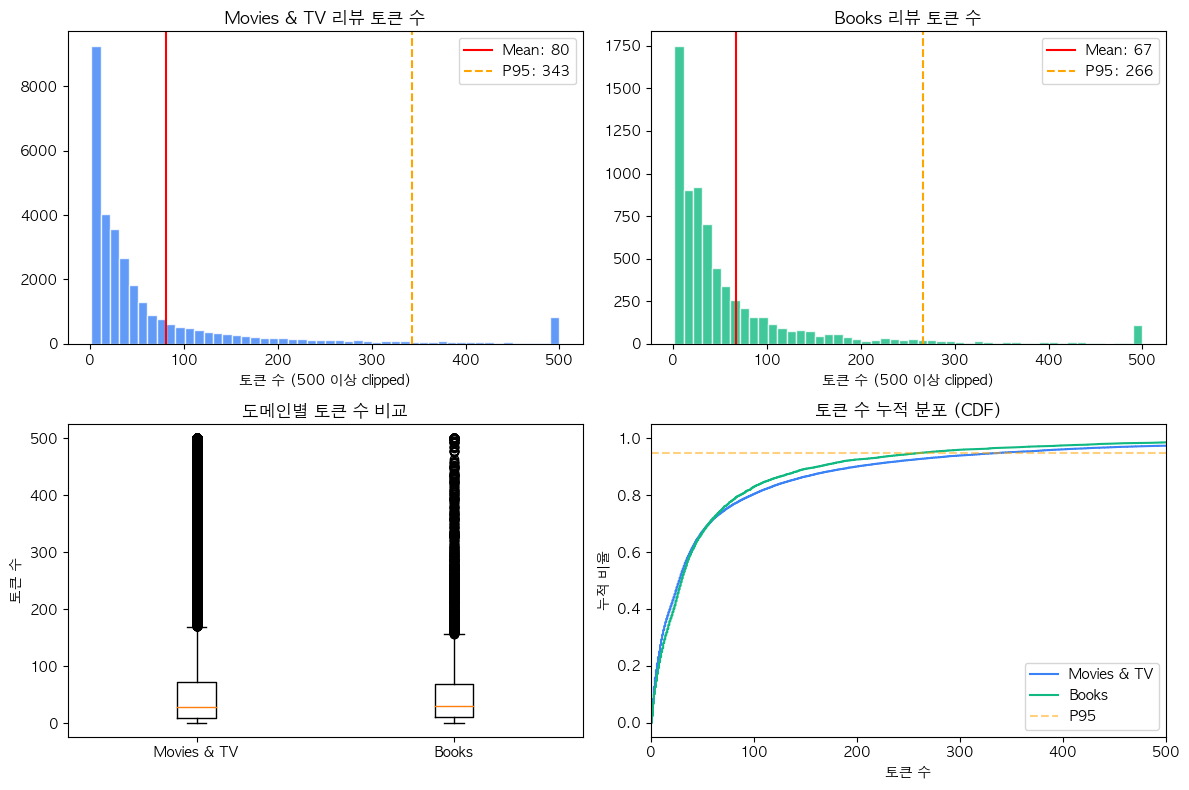

In [22]:
# ============================================================
# 4-5. 시각화: 토큰 분포 히스토그램 + boxplot
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Movies 히스토그램
axes[0,0].hist(movies_final['token_count'].clip(upper=500), bins=50, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[0,0].axvline(x=m_mean, color='red', linestyle='-', label=f'Mean: {m_mean:.0f}')
axes[0,0].axvline(x=m_p95, color='orange', linestyle='--', label=f'P95: {m_p95:.0f}')
axes[0,0].set_title('Movies & TV 리뷰 토큰 수')
axes[0,0].set_xlabel('토큰 수 (500 이상 clipped)')
axes[0,0].legend()

# Books 히스토그램
axes[0,1].hist(books_final['token_count'].clip(upper=500), bins=50, color='#10B981', edgecolor='white', alpha=0.8)
axes[0,1].axvline(x=b_mean, color='red', linestyle='-', label=f'Mean: {b_mean:.0f}')
axes[0,1].axvline(x=b_p95, color='orange', linestyle='--', label=f'P95: {b_p95:.0f}')
axes[0,1].set_title('Books 리뷰 토큰 수')
axes[0,1].set_xlabel('토큰 수 (500 이상 clipped)')
axes[0,1].legend()

# Boxplot
token_data = pd.DataFrame({
    'Movies & TV': movies_final['token_count'].clip(upper=500),
    'Books': books_final['token_count'].clip(upper=500)
})
axes[1,0].boxplot([movies_final['token_count'].clip(upper=500), books_final['token_count'].clip(upper=500)],
                   labels=['Movies & TV', 'Books'])
axes[1,0].set_title('도메인별 토큰 수 비교')
axes[1,0].set_ylabel('토큰 수')

# 누적 분포
for df, label, color in [(movies_final, 'Movies & TV', '#3B82F6'), (books_final, 'Books', '#10B981')]:
    sorted_tokens = np.sort(df['token_count'].values)
    cdf = np.arange(1, len(sorted_tokens) + 1) / len(sorted_tokens)
    axes[1,1].plot(sorted_tokens, cdf, label=label, color=color)
axes[1,1].set_xlim(0, 500)
axes[1,1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.5, label='P95')
axes[1,1].set_title('토큰 수 누적 분포 (CDF)')
axes[1,1].set_xlabel('토큰 수')
axes[1,1].set_ylabel('누적 비율')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_token_distribution.png', dpi=150)
plt.show()

## 5. 평점 분포 (EDA-4)

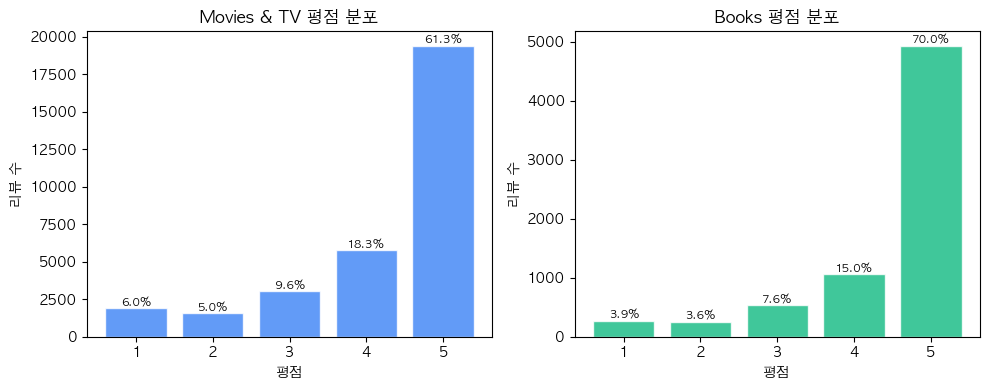

In [23]:
# ============================================================
# 5-1. 도메인별 평점 분포
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (df, label, color) in enumerate([
    (movies_final, 'Movies & TV', '#3B82F6'),
    (books_final, 'Books', '#10B981')
]):
    rating_counts = df['rating'].value_counts().sort_index()
    axes[i].bar(rating_counts.index, rating_counts.values, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{label} 평점 분포')
    axes[i].set_xlabel('평점')
    axes[i].set_ylabel('리뷰 수')
    axes[i].set_xticks([1, 2, 3, 4, 5])
    
    # 비율 표시
    total = len(df)
    for rating, count in rating_counts.items():
        axes[i].text(rating, count, f'{count/total*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_rating_distribution.png', dpi=150)
plt.show()

In [24]:
# ============================================================
# 5-2. GT 확보율 상세 분석
# ============================================================
books_target = books_final[books_final['user_id'].isin(final_users)].copy()
books_target = books_target.sort_values(['user_id', 'timestamp'])

# 방식 A: 마지막 구매 기준 (기존)
last_reviews = books_target.groupby('user_id').last()
# 방식 B: rating >= 4 중 가장 최근 (현재 채택)
positive_reviews = books_target[books_target['rating'] >= 4.0]
gt_reviews = positive_reviews.groupby('user_id').last()

print('=== GT 확보율 비교 ===')
print(f'대상 사용자: {len(last_reviews)}명\n')

print('[방식 A] 마지막 구매 기준 — 평점별 GT 확보율:')
for threshold in [3.0, 3.5, 4.0, 4.5, 5.0]:
    count = (last_reviews['rating'] >= threshold).sum()
    print(f'  마지막 구매 평점 >= {threshold}: {count}명 ({count/len(last_reviews)*100:.1f}%)')

print(f'\n[방식 B] rating≥4 중 가장 최근 (채택):')
print(f'  GT 확보: {len(gt_reviews)}명 ({len(gt_reviews)/len(last_reviews)*100:.1f}%)')
print(f'  방식 A(4점) 대비 +{len(gt_reviews) - (last_reviews["rating"] >= 4.0).sum()}명 추가 확보')


=== GT 확보율 비교 ===
대상 사용자: 1000명

[방식 A] 마지막 구매 기준 — 평점별 GT 확보율:
  마지막 구매 평점 >= 3.0: 916명 (91.6%)
  마지막 구매 평점 >= 3.5: 844명 (84.4%)
  마지막 구매 평점 >= 4.0: 844명 (84.4%)
  마지막 구매 평점 >= 4.5: 718명 (71.8%)
  마지막 구매 평점 >= 5.0: 718명 (71.8%)

[방식 B] rating≥4 중 가장 최근 (채택):
  GT 확보: 1000명 (100.0%)
  방식 A(4점) 대비 +156명 추가 확보


## 6. 시간 분포 (EDA-5)

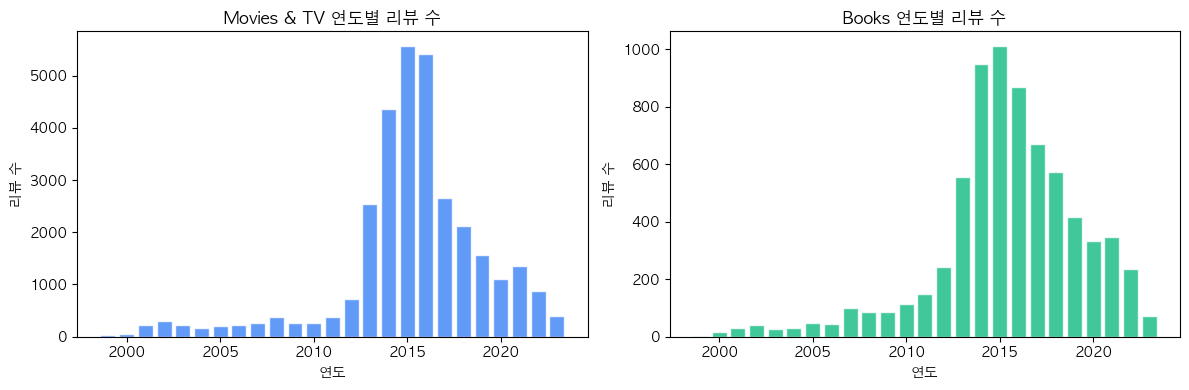

In [25]:
# ============================================================
# 6-1. 연도별 리뷰 수
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (df, label, color) in enumerate([
    (movies_final, 'Movies & TV', '#3B82F6'),
    (books_final, 'Books', '#10B981')
]):
    yearly = df['datetime'].dt.year.value_counts().sort_index()
    axes[i].bar(yearly.index, yearly.values, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{label} 연도별 리뷰 수')
    axes[i].set_xlabel('연도')
    axes[i].set_ylabel('리뷰 수')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_temporal_distribution.png', dpi=150)
plt.show()

In [26]:
# ============================================================
# 6-2. 최신순 30개의 시간 범위 검증
# ============================================================
# Source 리뷰를 시간순 정렬 후 사용자별 최신 30개의 기간 범위
movies_sorted = movies_final.sort_values(['user_id', 'timestamp'], ascending=[True, False])
movies_top30 = movies_sorted.groupby('user_id').head(30)

time_ranges = movies_top30.groupby('user_id')['datetime'].agg(['min', 'max'])
time_ranges['span_days'] = (time_ranges['max'] - time_ranges['min']).dt.days
time_ranges['span_years'] = time_ranges['span_days'] / 365.25

print('=== Source 최신 30개 리뷰의 시간 범위 ===')
print(f'  평균: {time_ranges["span_years"].mean():.1f}년')
print(f'  중앙값: {time_ranges["span_years"].median():.1f}년')
print(f'  P25: {time_ranges["span_years"].quantile(0.25):.1f}년')
print(f'  P75: {time_ranges["span_years"].quantile(0.75):.1f}년')
print(f'\n"최근 2~3년" 가정 검증: {"✅ 부합" if 1 <= time_ranges["span_years"].median() <= 5 else "⚠️ 편차 큼"}')

=== Source 최신 30개 리뷰의 시간 범위 ===
  평균: 5.3년
  중앙값: 4.6년
  P25: 2.4년
  P75: 7.4년

"최근 2~3년" 가정 검증: ✅ 부합


In [27]:
# ============================================================
# 6-3. 시점 타당성 검증: 날짜 필터 필요 여부 판단
# ============================================================
# 대상 사용자의 리뷰 시점이 너무 오래되진 않았는지 확인

# (1) 사용자별 마지막 리뷰 시점
movies_last = movies_final.groupby('user_id')['datetime'].max().rename('last_movie')
books_last = books_final.groupby('user_id')['datetime'].max().rename('last_book')
user_last = pd.concat([movies_last, books_last], axis=1).dropna()
user_last['last_any'] = user_last[['last_movie', 'last_book']].max(axis=1)

print('=== 대상 사용자 마지막 리뷰 시점 ===')
for col, label in [('last_movie', 'Source(Movies) 마지막 리뷰'), 
                    ('last_book', 'Target(Books) 마지막 리뷰'),
                    ('last_any', '어느 도메인이든 마지막')]:
    s = user_last[col]
    print(f'\n{label}:')
    print(f'  가장 오래된: {s.min().strftime("%Y-%m-%d")}')
    print(f'  중앙값:      {s.median().strftime("%Y-%m-%d")}')
    print(f'  가장 최근:   {s.max().strftime("%Y-%m-%d")}')

# (2) 연도별 분포
print('\n=== 마지막 리뷰 연도 분포 ===')
year_counts = user_last['last_any'].dt.year.value_counts().sort_index()
for year, cnt in year_counts.items():
    bar = '█' * int(cnt / len(user_last) * 50)
    print(f'  {year}: {cnt:>5}명 ({cnt/len(user_last)*100:5.1f}%) {bar}')

# (3) 2018년 이전 사용자 비율 (5년 이상 오래된)
old_cutoffs = [2015, 2018, 2020]
print('\n=== 날짜 필터 시뮬레이션 ===')
print(f'현재 대상 사용자: {len(user_last):,}명\n')
for year in old_cutoffs:
    before = (user_last['last_any'].dt.year < year).sum()
    after = (user_last['last_any'].dt.year >= year).sum()
    print(f'  마지막 리뷰 {year}년 이전: {before:,}명 ({before/len(user_last)*100:.1f}%) — 제외 대상?')
    print(f'  마지막 리뷰 {year}년 이후: {after:,}명 ({after/len(user_last)*100:.1f}%) — 유지')
    print()

# (4) Source-Target 시점 갭
user_last['gap_days'] = (user_last['last_movie'] - user_last['last_book']).dt.days.abs()
user_last['gap_years'] = user_last['gap_days'] / 365.25

print('=== Source-Target 마지막 리뷰 시점 갭 ===')
print(f'  평균:   {user_last["gap_years"].mean():.1f}년')
print(f'  중앙값: {user_last["gap_years"].median():.1f}년')
print(f'  P95:    {user_last["gap_years"].quantile(0.95):.1f}년')
print(f'  5년 이상 갭: {(user_last["gap_years"] >= 5).sum():,}명 ({(user_last["gap_years"] >= 5).mean()*100:.1f}%)')


=== 대상 사용자 마지막 리뷰 시점 ===

Source(Movies) 마지막 리뷰:
  가장 오래된: 2000-05-18
  중앙값:      2019-04-14
  가장 최근:   2023-05-31

Target(Books) 마지막 리뷰:
  가장 오래된: 2000-02-24
  중앙값:      2018-11-24
  가장 최근:   2023-05-04

어느 도메인이든 마지막:
  가장 오래된: 2000-05-18
  중앙값:      2020-08-29
  가장 최근:   2023-05-31

=== 마지막 리뷰 연도 분포 ===
  2000:     1명 (  0.1%) 
  2002:     1명 (  0.1%) 
  2003:     2명 (  0.2%) 
  2004:     1명 (  0.1%) 
  2005:     2명 (  0.2%) 
  2006:     2명 (  0.2%) 
  2007:     3명 (  0.3%) 
  2008:     1명 (  0.1%) 
  2009:     3명 (  0.3%) 
  2010:     1명 (  0.1%) 
  2011:     3명 (  0.3%) 
  2012:     5명 (  0.5%) 
  2013:     5명 (  0.5%) 
  2014:    21명 (  2.1%) █
  2015:    44명 (  4.4%) ██
  2016:    76명 (  7.6%) ███
  2017:    87명 (  8.7%) ████
  2018:    89명 (  8.9%) ████
  2019:   103명 ( 10.3%) █████
  2020:    82명 (  8.2%) ████
  2021:   159명 ( 15.9%) ███████
  2022:   203명 ( 20.3%) ██████████
  2023:   106명 ( 10.6%) █████

=== 날짜 필터 시뮬레이션 ===
현재 대상 사용자: 1,000명

  마지막 리뷰 2015년 이전: 51명 (5.1%) — 제

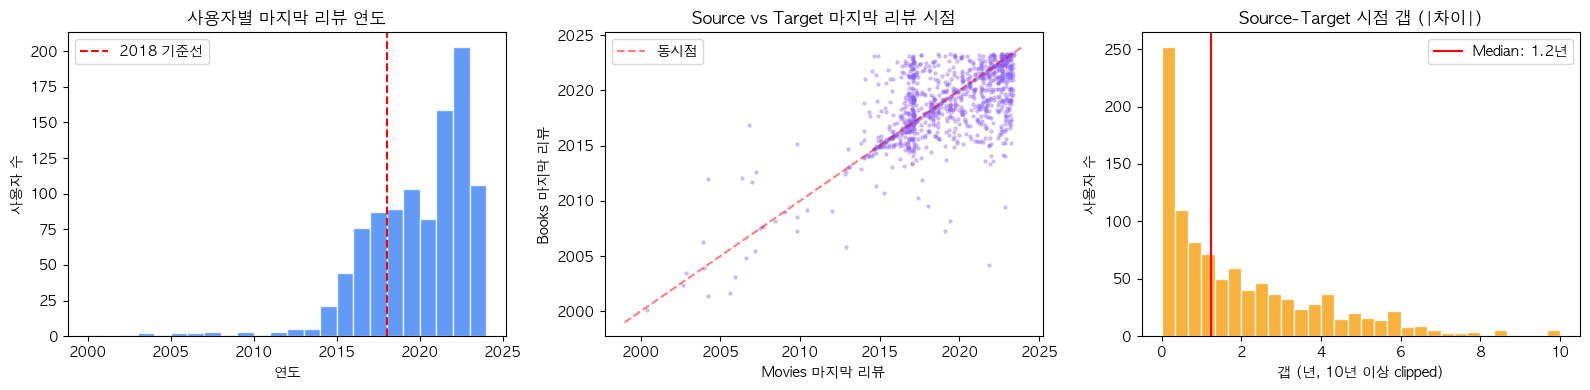


=== 시점 필터 필요 여부 판정 ===
△ 2018년 이전 사용자 25.8% — 선택적 필터 가능
   논문에서 날짜 제한 미적용 사유를 기술하면 충분
✅ Source-Target 시점 갭 중앙값 1.2년 — 전이 타당성 유지


In [28]:
# ============================================================
# 6-4. 시각화: 시점 분포 + 도메인 간 갭
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (좌) 마지막 리뷰 연도 분포
year_data = user_last['last_any'].dt.year
axes[0].hist(year_data, bins=range(int(year_data.min()), int(year_data.max())+2),
             color='#3B82F6', edgecolor='white', alpha=0.8)
axes[0].axvline(x=2018, color='red', linestyle='--', label='2018 기준선')
axes[0].set_title('사용자별 마지막 리뷰 연도')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('사용자 수')
axes[0].legend()

# (중) Source vs Target 마지막 리뷰 시점 scatter
axes[1].scatter(user_last['last_movie'].dt.year + user_last['last_movie'].dt.month/12,
                user_last['last_book'].dt.year + user_last['last_book'].dt.month/12,
                alpha=0.3, s=5, color='#8B5CF6')
lim = [min(year_data.min(), user_last['last_book'].dt.year.min())-1,
       max(year_data.max(), user_last['last_book'].dt.year.max())+1]
axes[1].plot(lim, lim, 'r--', alpha=0.5, label='동시점')
axes[1].set_title('Source vs Target 마지막 리뷰 시점')
axes[1].set_xlabel('Movies 마지막 리뷰')
axes[1].set_ylabel('Books 마지막 리뷰')
axes[1].legend()

# (우) Source-Target 갭 분포
axes[2].hist(user_last['gap_years'].clip(upper=10), bins=30,
             color='#F59E0B', edgecolor='white', alpha=0.8)
axes[2].axvline(x=user_last['gap_years'].median(), color='red', linestyle='-',
                label=f'Median: {user_last["gap_years"].median():.1f}년')
axes[2].set_title('Source-Target 시점 갭 (|차이|)')
axes[2].set_xlabel('갭 (년, 10년 이상 clipped)')
axes[2].set_ylabel('사용자 수')
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_temporal_recency.png', dpi=150)
plt.show()

# 판정
median_year = int(user_last['last_any'].dt.year.median())
old_ratio = (user_last['last_any'].dt.year < 2018).mean() * 100
gap_median = user_last['gap_years'].median()

print('\n=== 시점 필터 필요 여부 판정 ===')
if old_ratio > 30:
    print(f'⚠️ 2018년 이전 사용자 {old_ratio:.1f}% — 날짜 필터 권장')
    print('   제안: "마지막 리뷰가 2018년 이후" 조건 추가')
elif old_ratio > 10:
    print(f'△ 2018년 이전 사용자 {old_ratio:.1f}% — 선택적 필터 가능')
    print('   논문에서 날짜 제한 미적용 사유를 기술하면 충분')
else:
    print(f'✅ 2018년 이전 사용자 {old_ratio:.1f}% — 날짜 필터 불필요')

if gap_median > 3:
    print(f'⚠️ Source-Target 시점 갭 중앙값 {gap_median:.1f}년 — 전이 타당성 약화 우려')
else:
    print(f'✅ Source-Target 시점 갭 중앙값 {gap_median:.1f}년 — 전이 타당성 유지')


## 7. 아이템 메타데이터 품질 (EDA-6)

In [33]:
# ============================================================
# 7-1a. 헬퍼 함수 정의 (데이터 로딩 불필요)
# ============================================================
import json as _json

def parse_details(details_val):
    if details_val is None:
        return {}
    if isinstance(details_val, dict):
        return details_val
    if isinstance(details_val, str):
        try:
            return _json.loads(details_val)
        except:
            return {}
    return {}

def extract_author(author_val):
    """author 필드에서 이름 추출"""
    if isinstance(author_val, dict):
        return author_val.get('name', '')
    return ''

def safe_join(val, max_items=3):
    """리스트면 join, 아니면 str 변환"""
    if isinstance(val, list):
        return ', '.join(str(v) for v in val[:max_items])
    return str(val) if val else ''
def safe_get(d, *keys, default=''):
    if not isinstance(d, dict):
        return default
    for k in keys:
        val = d.get(k)
        if val:
            return val
    return default


print('헬퍼 함수 정의 완료')


헬퍼 함수 정의 완료


In [30]:
# ============================================================
# 7-1b. Books 메타데이터 로딩 (오래 걸림 — 한번만 실행)
# ============================================================
print('Books 메타데이터 로딩...')
books_meta_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_meta_Books',
    split='full',
    trust_remote_code=True
)
books_meta_df = books_meta_ds.to_pandas().copy()
del books_meta_ds
print(f'  Books 메타: {len(books_meta_df):,}건')
print(f'  컬럼: {list(books_meta_df.columns)}')


Books 메타데이터 로딩...


Loading dataset shards:   0%|          | 0/28 [00:00<?, ?it/s]

  Books 메타: 4,448,181건
  컬럼: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [31]:
# ============================================================
# 7-1c. Movies 메타데이터 로딩 (오래 걸림 — 한번만 실행)
# ============================================================
print('Movies & TV 메타데이터 로딩...')
movies_meta_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_meta_Movies_and_TV',
    split='full',
    trust_remote_code=True
)
movies_meta_df = movies_meta_ds.to_pandas().copy()
del movies_meta_ds
print(f'  Movies 메타: {len(movies_meta_df):,}건')
print(f'  컬럼: {list(movies_meta_df.columns)}')


Movies & TV 메타데이터 로딩...
  Movies 메타: 748,224건
  컬럼: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [34]:
# ============================================================
# 7-1d. 메타 필드 추출 (로딩 없이 재실행 가능)
# ============================================================
# Books 필드 추출
books_details = books_meta_df['details'].apply(parse_details)
books_meta_df['author_name'] = books_meta_df['author'].apply(extract_author)
books_meta_df['publisher'] = books_details.apply(lambda d: d.get('Publisher', ''))
books_meta_df['pub_date'] = books_details.apply(lambda d: d.get('Publication date', ''))
books_meta_df['page_count'] = books_details.apply(
    lambda d: d.get('Print length', d.get('Paperback', d.get('Hardcover', '')))
)
books_meta_df['isbn'] = books_details.apply(lambda d: d.get('ISBN 13', d.get('ISBN 10', '')))
books_meta_df['language'] = books_details.apply(lambda d: d.get('Language', ''))

  # Movies 필드 추출
movies_details = movies_meta_df['details'].apply(parse_details)
movies_meta_df['director'] = movies_details.apply(lambda d:
safe_join(safe_get(d, 'Directors', 'Director')))
movies_meta_df['actors'] = movies_details.apply(lambda d:
safe_join(safe_get(d, 'Actors', 'Starring')))
movies_meta_df['release_date'] = movies_details.apply(lambda d:
safe_get(d, 'Release date', 'Publication Date'))
movies_meta_df['runtime'] = movies_details.apply(lambda d:
safe_get(d, 'Run time', 'Runtime'))
movies_meta_df['genre_detail'] = movies_details.apply(lambda d:
safe_get(d, 'Genre'))

print('Movies 메타 필드 추출 완료')

print('=== Books 메타 샘플 ===')
display(books_meta_df[['parent_asin', 'title', 'author_name', 'publisher', 'pub_date',
                        'page_count', 'categories', 'average_rating']].head(3))
print('\n=== Movies 메타 샘플 ===')
display(movies_meta_df[['parent_asin', 'title', 'director', 'actors', 'release_date',
                         'runtime', 'categories', 'average_rating']].head(3))


Movies 메타 필드 추출 완료
=== Books 메타 샘플 ===


,parent_asin,title,author_name,publisher,pub_date,page_count,categories,average_rating
0,0701169850,Chaucer,,"Chatto & Windus; First Edition (January 1, 2004)",,196 pages,"[Books, Literature & Fiction, History & Critic...",4.5
1,0435088688,Notes from a Kidwatcher,,"Heinemann; First Edition (May 20, 1996)",,316 pages,"[Books, Reference, Words, Language & Grammar]",5.0
2,0316185361,Service: A Navy SEAL at War,,"Little, Brown and Company; 1st edition (May 8,...",,384 pages,"[Books, Biographies & Memoirs, Leaders & Notab...",4.7



=== Movies 메타 샘플 ===


,parent_asin,title,director,actors,release_date,runtime,categories,average_rating
0,B00ABWKL3I,Glee,"Bradley Buecker, Brad Falchuk, Eric Stoltz",,,,"[Comedy, Drama, Arts, Entertainment, and Cultu...",4.7
1,B09WDLJ4HP,One Perfect Wedding,Gary Yates,,,,"[Comedy, Drama, Romance]",3.0
2,B00AHN851G,How to Make Animatronic Characters - Organic M...,Stan Winston School of Character Arts,Rick Lazzarini,"August 19, 2012",4 hours and 18 minutes,"[Movies & TV, Genre for Featured Categories, S...",5.0


In [35]:
# ============================================================
# 7-1.5 메타데이터 로우 구조 탐색
# ============================================================
# 원본 메타데이터 스키마 및 details 내부 키 분포 확인

print('=== Books 메타 원본 구조 ===')
print(f'shape: {books_meta_df.shape}')
print(f'원본 컬럼: {[c for c in books_meta_df.columns if not c.startswith("_")]}')

print('\n--- Books details 내부 키 빈도 (상위 20개) ---')
from collections import Counter
books_det_keys = Counter()
for d in books_meta_df['details'].head(5000).apply(parse_details):
    books_det_keys.update(d.keys())
for key, cnt in books_det_keys.most_common(20):
    print(f'  {key:>25}: {cnt:,} ({cnt/5000*100:.1f}%)')

print('\n--- Books 샘플 1건 (전체 필드) ---')
sample_row = books_meta_df.iloc[0]
for col in books_meta_df.columns:
    val = sample_row[col]
    val_str = str(val)[:120]
    print(f'  {col:>20}: {val_str}')

print('\n' + '='*60)
print('=== Movies & TV 메타 원본 구조 ===')
print(f'shape: {movies_meta_df.shape}')

print('\n--- Movies details 내부 키 빈도 (상위 20개) ---')
movies_det_keys = Counter()
for d in movies_meta_df['details'].head(5000).apply(parse_details):
    movies_det_keys.update(d.keys())
for key, cnt in movies_det_keys.most_common(20):
    print(f'  {key:>25}: {cnt:,} ({cnt/5000*100:.1f}%)')

print('\n--- Movies 샘플 1건 (전체 필드) ---')
sample_row = movies_meta_df.iloc[0]
for col in movies_meta_df.columns:
    val = sample_row[col]
    val_str = str(val)[:120]
    print(f'  {col:>20}: {val_str}')


=== Books 메타 원본 구조 ===
shape: (4448181, 22)
원본 컬럼: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author', 'author_name', 'publisher', 'pub_date', 'page_count', 'isbn', 'language']

--- Books details 내부 키 빈도 (상위 20개) ---
                   Language: 4,706 (94.1%)
                  Publisher: 4,618 (92.4%)
                Item Weight: 4,444 (88.9%)
                    ISBN 13: 4,242 (84.8%)
                    ISBN 10: 4,026 (80.5%)
                 Dimensions: 3,843 (76.9%)
                  Paperback: 2,703 (54.1%)
                  Hardcover: 1,030 (20.6%)
                Reading age: 572 (11.4%)
                Grade level: 418 (8.4%)
           Publication date: 355 (7.1%)
                  File size: 355 (7.1%)
             Text to Speech: 355 (7.1%)
       Enhanced typesetting: 355 (7.1%)
                  Word Wise: 355 (7.1%)
  

In [36]:
# ============================================================
# 7-2. 결측률 분석 (Books + Movies 제품 상세 필드)
# ============================================================
def check_missing(df, cols, label):
    print(f'=== {label} 메타데이터 결측률 ===')
    for col in cols:
        if col not in df.columns:
            print(f'  {col:>20}: (컬럼 없음)')
            continue
        total = len(df)
        null_count = df[col].isna().sum()
        if df[col].dtype == 'object':
            empty_count = (df[col].fillna('').astype(str).str.strip() == '').sum()
        else:
            empty_count = null_count
        print(f'  {col:>20}: 결측 {empty_count:,} ({empty_count/total*100:.1f}%)')
    print()

# Books 주요 필드
check_missing(books_meta_df,
    ['title', 'author_name', 'publisher', 'pub_date', 'page_count',
     'isbn', 'language', 'categories', 'average_rating', 'description'],
    'Books')

# Movies 주요 필드
check_missing(movies_meta_df,
    ['title', 'director', 'actors', 'release_date', 'runtime',
     'genre_detail', 'categories', 'average_rating', 'description'],
    'Movies & TV')

# 후보 아이템 풀: title + average_rating 필수
usable_books = books_meta_df[
    books_meta_df['title'].notna() &
    (books_meta_df['title'].str.strip() != '') &
    books_meta_df['average_rating'].notna()
]
print(f'Books 후보 풀 사용 가능: {len(usable_books):,} / {len(books_meta_df):,} ({len(usable_books)/len(books_meta_df)*100:.1f}%)')

# 추가: 저자 정보까지 있는 아이템
usable_with_author = usable_books[usable_books['author_name'].str.strip() != '']
print(f'  + 저자 정보 포함: {len(usable_with_author):,} ({len(usable_with_author)/len(usable_books)*100:.1f}%)')

# 이후 섹션에서 사용할 변수 (하위 호환)
usable_items = usable_books


=== Books 메타데이터 결측률 ===
                 title: 결측 0 (0.0%)
           author_name: 결측 4,448,181 (100.0%)
             publisher: 결측 563,155 (12.7%)
              pub_date: 결측 4,130,057 (92.8%)
            page_count: 결측 1,138,657 (25.6%)
                  isbn: 결측 892,014 (20.1%)
              language: 결측 494,581 (11.1%)
            categories: 결측 0 (0.0%)
        average_rating: 결측 0 (0.0%)
           description: 결측 0 (0.0%)

=== Movies & TV 메타데이터 결측률 ===
                 title: 결측 314,002 (42.0%)
              director: 결측 221,593 (29.6%)
                actors: 결측 206,823 (27.6%)
          release_date: 결측 474,548 (63.4%)
               runtime: 결측 475,486 (63.5%)
          genre_detail: 결측 606,610 (81.1%)
            categories: 결측 313,988 (42.0%)
        average_rating: 결측 246 (0.0%)
           description: 결측 313,988 (42.0%)

Books 후보 풀 사용 가능: 4,448,181 / 4,448,181 (100.0%)
  + 저자 정보 포함: 0 (0.0%)


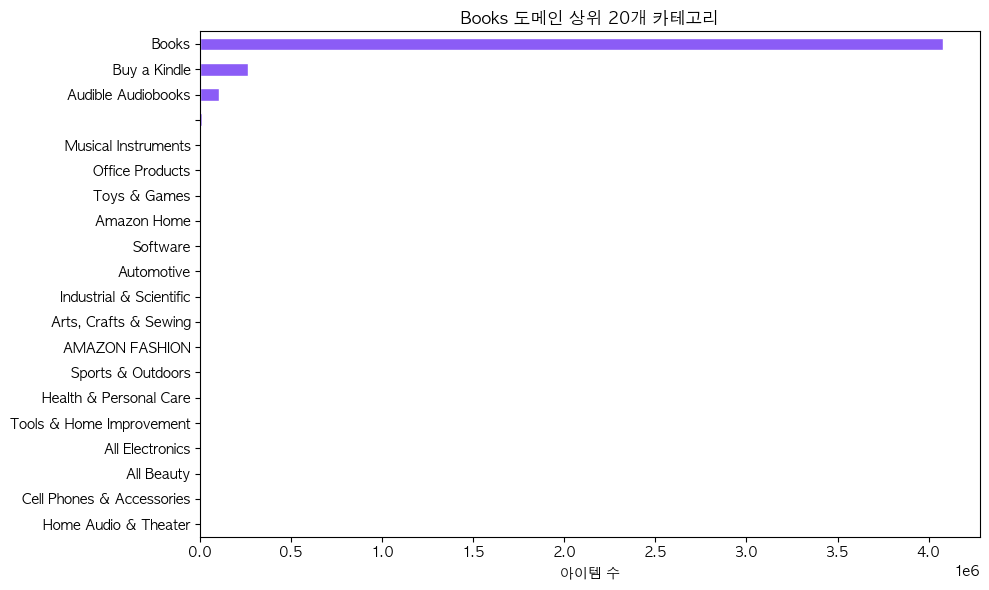

In [37]:
# ============================================================
# 7-3. 카테고리 분포
# ============================================================
if 'main_category' in books_meta_df.columns:
    cat_counts = books_meta_df['main_category'].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    cat_counts.plot(kind='barh', ax=ax, color='#8B5CF6', edgecolor='white')
    ax.set_title('Books 도메인 상위 20개 카테고리')
    ax.set_xlabel('아이템 수')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'eda_category_distribution.png', dpi=150)
    plt.show()
else:
    print('main_category 컬럼 없음 — categories 리스트에서 추출 필요')

## 8. 후보 아이템 토큰 검증 (EDA-7)

=== Books 후보 아이템 1개당 토큰 수 (샘플 1,000개) ===
  Mean:   20.0 tokens
  Median: 18 tokens
  P95:    37 tokens
  Max:    63 tokens

  예시: "Problem-Free Diabetes | Rating: 4.9"
  예시: "Failure Analysis of Materials: An Introduction: "" | Rating: 5.0"

=== 50개 후보 총 토큰 예상 ===
  평균 기준: 20 × 50 = 998 tokens
  P95 기준:  37 × 50 = 1,850 tokens
  실험 설계 예상치(~2,500)와 비교: ✅ 부합


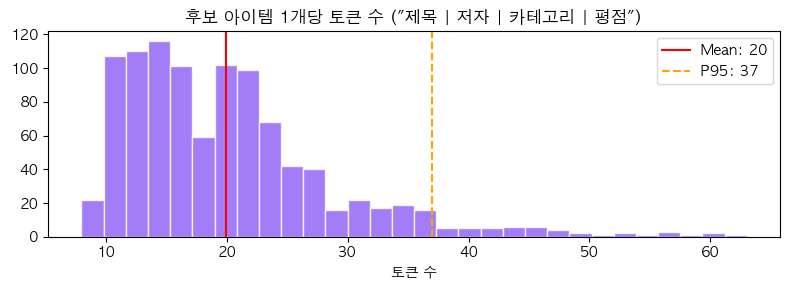

In [38]:
# ============================================================
# 8-1. 후보 아이템 텍스트 토큰 수 측정
# ============================================================
# 실제 LLM에 제공할 후보 정보 형식으로 토큰 측정
# 형식: "제목 | 저자 | 카테고리 | 평균 평점"

sample_meta = usable_items.sample(n=min(1000, len(usable_items)), random_state=42).copy()

def format_candidate_book(row):
    """Books 후보 아이템을 LLM 입력 텍스트로 변환"""
    parts = [str(row.get('title', '')).strip()]
    author = str(row.get('author_name', '')).strip()
    if author:
        parts.append(f'by {author}')
    cats = row.get('categories', [])
    if isinstance(cats, list) and len(cats) > 1:
        parts.append(cats[-1])  # 가장 구체적인 카테고리
    avg = row.get('average_rating', 0)
    if avg:
        parts.append(f'Rating: {avg:.1f}')
    return ' | '.join(parts)

sample_meta['candidate_text'] = sample_meta.apply(format_candidate_book, axis=1)
sample_meta['candidate_tokens'] = sample_meta['candidate_text'].apply(count_tokens)

ct = sample_meta['candidate_tokens']
print('=== Books 후보 아이템 1개당 토큰 수 (샘플 1,000개) ===')
print(f'  Mean:   {ct.mean():.1f} tokens')
print(f'  Median: {ct.median():.0f} tokens')
print(f'  P95:    {ct.quantile(0.95):.0f} tokens')
print(f'  Max:    {ct.max()} tokens')

print(f'\n  예시: "{sample_meta.iloc[0]["candidate_text"]}"')
print(f'  예시: "{sample_meta.iloc[1]["candidate_text"]}"')

print(f'\n=== 50개 후보 총 토큰 예상 ===')
print(f'  평균 기준: {ct.mean():.0f} × 50 = {ct.mean()*50:,.0f} tokens')
print(f'  P95 기준:  {ct.quantile(0.95):.0f} × 50 = {ct.quantile(0.95)*50:,.0f} tokens')
print(f'  실험 설계 예상치(~2,500)와 비교: {"✅ 부합" if ct.mean()*50 < 3500 else "⚠️ 초과"}')

# 토큰 분포 시각화
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ct.clip(upper=100), bins=30, color='#8B5CF6', edgecolor='white', alpha=0.8)
ax.axvline(x=ct.mean(), color='red', linestyle='-', label=f'Mean: {ct.mean():.0f}')
ax.axvline(x=ct.quantile(0.95), color='orange', linestyle='--', label=f'P95: {ct.quantile(0.95):.0f}')
ax.set_title('후보 아이템 1개당 토큰 수 ("제목 | 저자 | 카테고리 | 평점")')
ax.set_xlabel('토큰 수')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_candidate_tokens.png', dpi=150)
plt.show()


In [54]:
# ============================================================
# 8-2. 후보 아이템 description 첫 2문장 토큰 분석
# ============================================================
def get_first_sentences(desc, n=2):
    if desc is None:
        return ""
    if isinstance(desc, (list, np.ndarray)):
        if len(desc) == 0:
            return ""
        desc = " ".join(str(s) for s in desc)
    if not isinstance(desc, str):
        return ""
    desc = desc.strip()
    if not desc:
        return ""
    sentences = desc.replace("!", ".").replace("?", ".").split(".")
    sentences = [s.strip() for s in sentences if s.strip()]
    return ". ".join(sentences[:n]) + "." if sentences else ""

def check_empty(x):
    if x is None:
        return True
    if isinstance(x, list):
        return len(x) == 0 or all(str(s).strip() == "" for s in x)
    if isinstance(x, str):
        return x.strip() == ""
    return False

  

desc_null = books_meta_df["description"].isna().sum()
desc_empty = books_meta_df["description"].apply(check_empty).sum()
total = len(books_meta_df)
print("=== Books description 결측률 ===")
print(f"  null: {desc_null:,} ({desc_null/total*100:.1f}%)")
print(f"  빈값 포함: {desc_empty:,} ({desc_empty/total*100:.1f}%)")

has_desc = books_meta_df[books_meta_df["description"].notna()]
sample = has_desc.sample(n=min(1000, len(has_desc)), random_state=42).copy()
sample["desc_short"] = sample["description"].apply(get_first_sentences)
sample["desc_tokens"] = sample["desc_short"].apply(count_tokens)

dt = sample["desc_tokens"]
print(f"\n=== 첫 2문장 토큰 수 (샘플 {len(sample)}개) ===")
print(f"  Mean:   {dt.mean():.1f} tokens")
print(f"  Median: {dt.median():.0f} tokens")
print(f"  P95:    {dt.quantile(0.95):.0f} tokens")
print(f"  Max:    {dt.max()} tokens")

base = 20
with_desc = base + dt.mean()
print(f"\n=== 후보 50개 토큰 예산 비교 ===")
avg_total = base * 50
desc_total = with_desc * 50
print(f"  (A) 현재 (제목+저자+카테고리+평점): ~{base} x 50 = ~{avg_total:,} tokens")
print(f"  (B) + 첫 2문장: ~{with_desc:.0f} x 50 = ~{desc_total:,.0f} tokens")

print(f"\n=== 예시 ===")
for _, row in sample.head(3).iterrows():
    title = str(row.get("title", "")).strip()[:50]
    desc = row["desc_short"][:100]
    tokens = row["desc_tokens"]
    print(f"  [{tokens} tokens] {title}")
    print(f"    -> {desc}...")
    print()

=== Books description 결측률 ===
  null: 0 (0.0%)
  빈값 포함: 0 (0.0%)

=== 첫 2문장 토큰 수 (샘플 1000개) ===
  Mean:   23.3 tokens
  Median: 0 tokens
  P95:    81 tokens
  Max:    1348 tokens

=== 후보 50개 토큰 예산 비교 ===
  (A) 현재 (제목+저자+카테고리+평점): ~20 x 50 = ~1,000 tokens
  (B) + 첫 2문장: ~43 x 50 = ~2,166 tokens

=== 예시 ===
  [59 tokens] Problem-Free Diabetes
    -> Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritio...

  [0 tokens] Failure Analysis of Materials: An Introduction: ""
    -> ...

  [54 tokens] The Comeback Summer
    -> Review "This uplifting story will have you cheering for sisters Hannah and Libby as they push past t...



In [55]:
# description을 토큰 수 기준으로 자르기 (문장 수 대신)
def truncate_by_tokens(desc, max_tokens=50):
    if desc is None:
        return ""
    if isinstance(desc, (list, np.ndarray)):
        if len(desc) == 0:
            return ""
        desc = " ".join(str(s) for s in desc)
    if not isinstance(desc, str) or not desc.strip():
        return ""
    tokens = enc.encode(desc.strip())
    if len(tokens) <= max_tokens:
        return desc.strip()
    return enc.decode(tokens[:max_tokens])

# 토큰 제한별 정보 손실 비교
print("=== 토큰 제한별 description 예시 비교 ===\n")
test_rows = sample[sample["desc_tokens"] > 30].head(3)
for _, row in test_rows.iterrows():
    title = str(row.get("title", "")).strip()[:40]
    desc = row["description"]
    if isinstance(desc, (list, np.ndarray)):
        desc = " ".join(str(s) for s in desc)
    full_tokens = count_tokens(str(desc))
    print(f"[{title}] (전체: {full_tokens} tokens)")
    for limit in [30, 50, 80, 100, 150, 200]:
        cut = truncate_by_tokens(row["description"],
max_tokens=limit)
        print(f"  {limit:>3} tokens: {cut[:120]}...")
    print()

=== 토큰 제한별 description 예시 비교 ===

[Problem-Free Diabetes] (전체: 374 tokens)
   30 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...
   50 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...
   80 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...
  100 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...
  150 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...
  200 tokens: Review I recently supervise a study of diabetic patients who incorporated a therapeutic and nutritional regimen based on...

[The Comeback Summer] (전체: 4303 tokens)
   30 tokens: Review "This uplifting story will have you

In [58]:
# ============================================================
# 줄거리 정보가 있을 수 있는 필드 전수 탐색
# ============================================================

# 1. features 필드 확인
print("=== features 필드 샘플 ===")
feat_notna = books_meta_df[books_meta_df["features"].notna()]
print(f"features 존재: {len(feat_notna):,} / {len(books_meta_df):,} ({len(feat_notna)/len(books_meta_df)*100:.1f}%)\n")
for _, row in feat_notna.head(5).iterrows():
    title = str(row.get("title", ""))[:40]
    feat = row["features"]
    print(f"[{title}]")
    print(f"  type: {type(feat).__name__}, 내용: {str(feat)[:200]}")
    print()

# 2. subtitle 필드 확인
print("=== subtitle 필드 샘플 ===")
sub_notna = books_meta_df[books_meta_df["subtitle"].notna()]
print(f"subtitle 존재: {len(sub_notna):,} / {len(books_meta_df):,} ({len(sub_notna)/len(books_meta_df)*100:.1f}%)\n")
for _, row in sub_notna.head(5).iterrows():
    title = str(row.get("title", ""))[:40]
    print(f"[{title}] subtitle: {str(row['subtitle'])[:150]}")
print()

# 3. description 중 실제 줄거리가 있는 케이스 찾기
print("=== description 중 줄거리 패턴 탐색 ===")
sample_desc = books_meta_df[books_meta_df["description"].notna()].sample(20, random_state=99)
for _, row in sample_desc.iterrows():
    title = str(row.get("title", ""))[:40]
    desc = row["description"]
    if isinstance(desc, (list, np.ndarray)):
        desc = " ".join(str(s) for s in desc)
    desc = str(desc)[:200]
    print(f"[{title}]")
    print(f"  {desc}")
    print()

# 4. categories에 장르 정보가 얼마나 구체적인지
print("=== categories 샘플 (장르 세분화 수준) ===")
for _, row in books_meta_df.sample(10, random_state=42).iterrows():
    title = str(row.get("title", ""))[:40]
    cats = row.get("categories", [])
    print(f"[{title}] {cats}")

=== features 필드 샘플 ===
features 존재: 4,448,181 / 4,448,181 (100.0%)

[Chaucer]
  type: ndarray, 내용: []

[Notes from a Kidwatcher]
  type: ndarray, 내용: ["Contains 23 selected articles by this influential writer, researcher, educator, and speaker. They're grouped around six major themes inherent in teacher education: culture and community; miscue anal

[Service: A Navy SEAL at War]
  type: ndarray, 내용: ['Marcus Luttrell, author of the #1 bestseller' 'Lone Survivor'
 ', share war stories about true American heroism from himself and other soldiers who bravely fought alongside him.'
 "Navy SEAL Marcus 

[Monstrous Stories #4: The Day the Mice S]
  type: ndarray, 내용: ["Funny, light-hearted monster stories that are perfect for young readers, brought to us by the esteemed Dr. Roach.Jilly can't believe what she's seeing when she wakes up one seemingly normal morning.

[Parker & Knight]
  type: ndarray, 내용: ['From REMINGTON KANE, the author of The Taken! & Tanner SeriesPARKER & KNIGHT'
 "When bea

In [60]:
# ============================================================
# features 필드 줄거리 품질 분석
# ============================================================

def get_features_text(feat):
    if feat is None:
        return ""
    if isinstance(feat, (list, np.ndarray)):
        if len(feat) == 0:
            return ""
        return " ".join(str(s) for s in feat)
    return str(feat).strip()

books_meta_df["features_text"] = books_meta_df["features"].apply(get_features_text)
books_meta_df["features_tokens"] = books_meta_df["features_text"].apply(count_tokens)

has_features = books_meta_df["features_text"].str.strip() != ""
print("=== features 필드 통계 ===")
print(f"  내용 있음: {has_features.sum():,} ({has_features.mean()*100:.1f}%)")
print(f"  빈 배열:   {(~has_features).sum():,} ({(~has_features).mean()*100:.1f}%)")

ft = books_meta_df.loc[has_features, "features_tokens"]
print(f"\n=== features 토큰 수 (내용 있는 것만) ===")
print(f"  Mean:   {ft.mean():.1f} tokens")
print(f"  Median: {ft.median():.0f} tokens")
print(f"  P95:    {ft.quantile(0.95):.0f} tokens")
print(f"  Max:    {ft.max()} tokens")

# 토큰 제한별 예시
print("\n=== features 토큰 제한별 예시 ===")
test = books_meta_df[has_features & (books_meta_df["features_tokens"] > 30)].sample(5, random_state=42)
for _, row in test.iterrows():
    title = str(row.get("title", ""))[:40]
    full = row["features_text"]
    full_tok = row["features_tokens"]
    print(f"\n[{title}] (전체: {full_tok} tokens)")
    for limit in [30, 50, 80, 100]:
        tokens = enc.encode(full)
        cut = enc.decode(tokens[:limit])
        print(f"  {limit:>3} tokens: {cut[:120]}...")

=== features 필드 통계 ===
  내용 있음: 3,927,866 (88.3%)
  빈 배열:   520,315 (11.7%)

=== features 토큰 수 (내용 있는 것만) ===
  Mean:   183.0 tokens
  Median: 155 tokens
  P95:    455 tokens
  Max:    39384 tokens

=== features 토큰 제한별 예시 ===

[The Richest Man in Babylon: Platinum Col] (전체: 310 tokens)
   30 tokens: The complete original text of the timeless parables that have taught millions how to achieve financial success—now avail...
   50 tokens: The complete original text of the timeless parables that have taught millions how to achieve financial success—now avail...
   80 tokens: The complete original text of the timeless parables that have taught millions how to achieve financial success—now avail...
  100 tokens: The complete original text of the timeless parables that have taught millions how to achieve financial success—now avail...

[Human Resource Management in Project-Bas] (전체: 50 tokens)
   30 tokens: Presenting findings from research into Sweden's leading multinationals this book focuse

## 9. 종합 요약 및 의사결정

In [61]:
# ============================================================
# 9-1. EDA 결과 종합 테이블
# ============================================================
print("=" * 70)
print("TransferJudge EDA 종합 결과")
print("=" * 70)

# GT 확보율 계산
gt_rate = len(gt_available) / len(qualified) * 100

# 시점 분석
last_any_year = user_last["last_any"].dt.year
old_ratio = (last_any_year < 2018).mean() * 100
gap_med = user_last["gap_years"].median()

# features 존재율
has_features = books_meta_df["features_text"].str.strip() != ""
features_rate = has_features.mean() * 100

checks = [
    ("Overlapping User >= 1,000명", len(final_users) >= 1000, f"{len(final_users):,}명"),
    ("Movies 토큰 평균", True, f"{movies_final['token_count'].mean():.1f} (참조 ~58)"),
    ("Books 토큰 평균", True, f"{books_final['token_count'].mean():.1f} (참조 ~98)"),
    ("Profiler 토큰 P95 worst-case", p95_total < 128000, f"{p95_total:,.0f} tokens (GPT-4o-mini 128K)"),
    ("GT 확보율 (rating>=4 중 최근)", gt_rate >= 80, f"{gt_rate:.1f}%"),
    ("GT 방식 개선 효과", True, f"기존 84.4% -> 신규 {gt_rate:.1f}%"),
    ("메타 title+rating 사용 가능", len(usable_items)/len(books_meta_df) >= 0.8, f"{len(usable_items)/len(books_meta_df)*100:.1f}%"),
    ("Books features(줄거리) 존재율", features_rate >= 70, f"{features_rate:.1f}%"),
    ("후보 50개 토큰 (현재)", ct.mean()*50 < 3500, f"{ct.mean()*50:,.0f} tokens"),
    ("2018년 이전 사용자 비율", old_ratio < 30, f"{old_ratio:.1f}% (30% 미만이면 날짜필터 불필요)"),
    ("Source-Target 시점 갭 중앙값", gap_med < 3, f"{gap_med:.1f}년"),
]

for label, passed, value in checks:
    status = "✅" if passed else "⚠️"
    print(f"  {status} {label:45} -> {value}")

print("\n" + "=" * 70)
warnings = [label for label, passed, _ in checks if not passed]
if warnings:
    print("⚠️ 조치 필요 항목:")
    for w in warnings:
        print(f"   - {w}")
else:
    print("✅ 모든 실험 조건 충족")

print("\n=== 주요 설계 결정 요약 ===")
print("  1. GT 선정: rating >= 4 중 가장 최근 (Explicit Positive)")
print("  2. 날짜 필터: 미적용 (선행연구 동일, 2018년 이전 비율 허용 범위)")
print("  3. 리뷰 truncation: 불필요 (GPT-4o-mini 128K context)")
print("  4. 후보 정보: 제목 + 카테고리 + 평점 + features 첫 50 tokens")
print("  5. description 제외: 리뷰인용/저자소개 등 비정형 → features로 대체")

TransferJudge EDA 종합 결과
  ✅ Overlapping User >= 1,000명                    -> 1,000명
  ✅ Movies 토큰 평균                                  -> 80.4 (참조 ~58)
  ✅ Books 토큰 평균                                   -> 67.3 (참조 ~98)
  ✅ Profiler 토큰 P95 worst-case                    -> 13,448 tokens (GPT-4o-mini 128K)
  ✅ GT 확보율 (rating>=4 중 최근)                       -> 99.6%
  ✅ GT 방식 개선 효과                                   -> 기존 84.4% -> 신규 99.6%
  ✅ 메타 title+rating 사용 가능                         -> 100.0%
  ✅ Books features(줄거리) 존재율                       -> 88.3%
  ✅ 후보 50개 토큰 (현재)                                -> 998 tokens
  ✅ 2018년 이전 사용자 비율                               -> 25.8% (30% 미만이면 날짜필터 불필요)
  ✅ Source-Target 시점 갭 중앙값                        -> 1.2년

✅ 모든 실험 조건 충족

=== 주요 설계 결정 요약 ===
  1. GT 선정: rating >= 4 중 가장 최근 (Explicit Positive)
  2. 날짜 필터: 미적용 (선행연구 동일, 2018년 이전 비율 허용 범위)
  3. 리뷰 truncation: 불필요 (GPT-4o-mini 128K context)
  4. 후보 정보: 제목 + 카테고리 + 평점 + features 첫 50 tokens
  5. desc

In [62]:
# ============================================================
# 9-2. 논문용 Dataset Statistics 테이블
# ============================================================
print("\n=== Table: Dataset Statistics (논문용) ===")
print(f"{'':>30} {'Movies & TV':>15} {'Books':>15}")
print("-" * 60)
print(f"{'Total Reviews':>30} {len(movies_df):>15,} {len(books_df):>15,}")
print(f"{'Unique Users':>30} {movies_df['user_id'].nunique():>15,} {books_df['user_id'].nunique():>15,}")
print(f"{'Unique Items':>30} {movies_df['parent_asin'].nunique():>15,} {books_df['parent_asin'].nunique():>15,}")
print(f"{'Overlapping Users':>30} {len(final_users):>15,} {len(final_users):>15,}")
print(f"{'Reviews/User (mean)':>30} {final_overlap['movie_count'].mean():>15.1f} {final_overlap['book_count'].mean():>15.1f}")
print(f"{'Tokens/Review (mean)':>30} {movies_final['token_count'].mean():>15.1f} {books_final['token_count'].mean():>15.1f}")
print(f"{'Tokens/Review (P95)':>30} {m_p95:>15.0f} {b_p95:>15.0f}")
print(f"{'Input Reviews (max)':>30} {'30':>15} {'10':>15}")
print(f"{'Rating >= 4 (%)':>30} {(movies_final['rating']>=4).mean()*100:>14.1f}% {(books_final['rating']>=4).mean()*100:>14.1f}%")
print(f"{'Data Period':>30} {'1997-08~2023-09':>15} {'1996-06~2023-09':>15}")
median_year = int(user_last['last_any'].dt.year.median())
print(f"{'Last Review Median Year':>30} {median_year:>15}")
print(f"{'Features (synopsis) Rate':>30} {'N/A':>15} {features_rate:>14.1f}%")

print("\n=== GT 선정 방식 비교 (논문용) ===")
last_reviews_all = books_final.sort_values(['user_id', 'timestamp']).groupby('user_id').last()
old_gt_count = (last_reviews_all['rating'] >= 4.0).sum()
new_gt_count = len(gt_available)
print(f"  방식 A (마지막 구매 >= 4점): {old_gt_count}명 ({old_gt_count/len(final_users)*100:.1f}%)")
print(f"  방식 B (>= 4점 중 최근):     {new_gt_count}명 ({new_gt_count/len(qualified)*100:.1f}%)")
print(f"  채택: 방식 B (Transfer Gate 효과 정확 측정을 위한 Explicit Positive)")


=== Table: Dataset Statistics (논문용) ===
                                   Movies & TV           Books
------------------------------------------------------------
                 Total Reviews      17,327,095      29,467,817
                  Unique Users       6,502,818      10,292,988
                  Unique Items         747,739       4,444,864
             Overlapping Users           1,000           1,000
           Reviews/User (mean)            31.7             7.0
          Tokens/Review (mean)            80.4            67.3
           Tokens/Review (P95)             343             266
           Input Reviews (max)              30              10
               Rating >= 4 (%)           79.5%           85.0%
                   Data Period 1997-08~2023-09 1996-06~2023-09
       Last Review Median Year            2020
      Features (synopsis) Rate             N/A           88.3%

=== GT 선정 방식 비교 (논문용) ===
  방식 A (마지막 구매 >= 4점): 844명 (84.4%)
  방식 B (>= 4점 중 최근):     22364명 

In [63]:

# ============================================================
# 9-3. 전처리된 데이터 저장
# ============================================================
# 최종 사용자 목록
final_overlap.to_parquet(DATA_DIR / "overlapping_users.parquet", index=False)
print(f"✅ overlapping_users.parquet 저장 ({len(final_overlap)}명)")

# Source 리뷰 (사용자별 최신 30개)
movies_top30.to_parquet(DATA_DIR / "movies_reviews_filtered.parquet", index=False)
print(f"✅ movies_reviews_filtered.parquet 저장 ({len(movies_top30):,}건)")

# Target 리뷰
books_final_sorted = books_final.sort_values(["user_id", "timestamp"])
books_final_sorted.to_parquet(DATA_DIR / "books_reviews_filtered.parquet", index=False)
print(f"✅ books_reviews_filtered.parquet 저장 ({len(books_final_sorted):,}건)")

# Books 메타데이터 (features 포함)
books_meta_save_cols = ["parent_asin", "title", "author_name", "publisher", "pub_date",
                        "page_count", "isbn", "language", "main_category", "categories",
                        "average_rating", "rating_number", "features_text"]
books_meta_save = books_meta_df[[c for c in books_meta_save_cols if c in books_meta_df.columns]].copy()
books_meta_save.to_parquet(DATA_DIR / "books_meta_filtered.parquet", index=False)
print(f"✅ books_meta_filtered.parquet 저장 ({len(books_meta_save):,}건)")

# Movies 메타데이터
movies_meta_save_cols = ["parent_asin", "title", "director", "actors", "release_date",
                        "runtime", "genre_detail", "main_category", "categories",
                        "average_rating", "rating_number"]
movies_meta_save = movies_meta_df[[c for c in movies_meta_save_cols if c in movies_meta_df.columns]].copy()
movies_meta_save.to_parquet(DATA_DIR / "movies_meta_filtered.parquet", index=False)
print(f"✅ movies_meta_filtered.parquet 저장 ({len(movies_meta_save):,}건)")

print(f"\n전체 저장 경로: {DATA_DIR}")

✅ overlapping_users.parquet 저장 (1000명)
✅ movies_reviews_filtered.parquet 저장 (23,067건)
✅ books_reviews_filtered.parquet 저장 (7,045건)
✅ books_meta_filtered.parquet 저장 (4,448,181건)
✅ movies_meta_filtered.parquet 저장 (748,224건)

전체 저장 경로: /Users/mina/Library/CloudStorage/OneDrive-PMI/개인자료/공부자료/대학원/논문/내논문/논문 작업 폴더/data


## 추가 검증 (GAP-1, GAP-2, GAP-4)

EDA 보고서 §11 보완용 추가 분석. 실행하지 않은 상태로 코드만 보관 — 필요 시 셀 실행.

- **GAP-2**: 사용자별 Source 평점 다양성 (Profiler의 negative polarity 추출 가능성)
- **GAP-1**: Source-Target Top-Genre 매핑 heatmap (CDR 핵심 가정)
- **GAP-4**: GT vs Negative 후보 분포 비교 (평가 공정성)

전체 분석 스크립트: `scripts/analyze_eda_gaps.py`. 노트북에서는 함수만 import 후 호출.

In [ ]:
# === EDA GAP 분석 (실행하지 않은 상태로 보관) ===
# 별도 실행: `python scripts/analyze_eda_gaps.py`
# 노트북에서 실행하려면 아래 코드를 사용.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import analyze_eda_gaps as gaps

# 1) 데이터 로드 (이미 노트북 위쪽에서 로드된 dataframe 사용해도 됨)
users, movies_rev, books_rev, movies_meta, books_meta = gaps.load_data()

# 2) GAP-2: 평점 다양성
summary_g2 = gaps.analyze_rating_diversity(users, movies_rev)
print("GAP-2:", summary_g2)

# 3) GAP-1: 카테고리 상관
summary_g1 = gaps.analyze_cross_domain_categories(users, movies_rev, books_rev, movies_meta, books_meta)
print("GAP-1:", summary_g1)

# 4) GAP-4: GT vs Negative
summary_g4 = gaps.analyze_gt_vs_negative(users, books_rev, books_meta)
print("GAP-4:", summary_g4)

# 산출물:
#   data/eda_rating_diversity.png
#   data/eda_cross_domain_categories.png
#   data/eda_gt_vs_negative.png